In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
#the temperature function
#def tempfit(t):
 #   fitt = 28.19874*(1 + 0.2476246*np.cos((np.pi/6)*(0.8089651*t-5.192219)))
  #  return fitt
#def tempfit(t):
 #   cost1 =  -3.568*np.cos((np.pi/6)*1.13937*t)
  #  cost2 =  7.96*np.cos(2*(np.pi/6)*1.13937*t) 
   # sint1 = -2.776*np.sin((np.pi/6)*1.13937*t)
    #sint2 = -2.278*np.sin(2*(np.pi/6)*1.13937*t)
                        
   # fitt = 30.666 -3.568*np.cos((np.pi/6)*1.13937*t) + 7.96*np.cos(2*(np.pi/6)*1.13937*t) -2.776*np.sin((np.pi/6)*1.13937*t) -2.278*np.sin(2*(np.pi/6)*1.13937*t)
    #fitt = 30.666 + cost1 + cost2 + sint1 + sint2
    #return fitt

In [3]:
def tempfit(t):
     cost1 =  -2.94069*np.cos((np.pi/6)*(-1.180806)*t)
     cost2 =  1.57860*np.cos(2*(np.pi/6)*(-1.180806)*t)
     cost3 = 0.640225*np.cos(3*(np.pi/6)*(-1.180806)*t)
     sint1 = 3.00629*np.sin((np.pi/6)*(-1.180806)*t)
     sint2 = 1.93711*np.sin(2*(np.pi/6)*(-1.180806)*t)
     sint3 = 1.5506*np.sin(3*(np.pi/6)*(-1.180806)*t)
                        
   # fitt = 30.666 -3.568*np.cos((np.pi/6)*1.13937*t) + 7.96*np.cos(2*(np.pi/6)*1.13937*t) -2.776*np.sin((np.pi/6)*1.13937*t) -2.278*np.sin(2*(np.pi/6)*1.13937*t)
     fitt = 30.9144 + cost1 + cost2 + cost3 + sint1 + sint2 + sint3
     return fitt

In [4]:
#the rainfall function
#def rainffit(t):
 #   t_mod = t % 12  # Get month position in annual cycle
    #t_mod = 12 if t_mod == 0 else t_mod  # Handle December
  #  if 5 <= t_mod <= 10:  # Wet season (May-Oct)
   #     return  22.91487*(1 + 1.048219*np.cos((np.pi/6)*(2.469001*t_mod-7.815061)))
        #return rainfit(t)
    #else:  # Dry season (Nov-Apr)
     #   return 0.0
def rainffit(t): 
    cosr1 = 14.158*np.cos((np.pi/6)*1.321*t)
    cosr2 =  2.0275*np.cos(2*(np.pi/6)*1.1321*t)
    cosr3 =  - 4.0865*np.cos(3*(np.pi/6)*1.321*t)
    sinr1 = -13.841*np.sin((np.pi/6)*1.321*t)
    sinr2 = -11.3745*np.sin(2*(np.pi/6)*1.321*t) 
    sinr3 = - 4.2508*np.sin(3*(np.pi/6)*1.321*t)
    rfft = 11.281 + cosr1 + cosr2 + cosr3 +sinr1 + sinr2 + sinr3
   # rfft = 11.281  + 14.158*np.cos((np.pi/6)*1.321*t) + 2.0275*np.cos(2*(np.pi/6)*1.1321*t) - 4.0865*np.cos(3*(np.pi/6)*1.321*t) -13.841*np.sin((np.pi/6)*1.321*t) -11.3745*np.sin(2*(np.pi/6)*1.321*t) - 4.2508*np.sin(3*(np.pi/6)*1.321*t)
    return rfft

In [5]:
#the temperature and rainfall dependent parameters
#the vectors bitting rate
def bit(t): 
    theta = -0.00014*((tempfit(t))**2) + 0.027*(tempfit(t)) - 0.322
    return theta

#the rate of vectors laying eggs
def eggn(t):
    b_v = -0.153*((tempfit(t))**2) + 8.61*(tempfit(t)) - 0.487
    return b_v
#immature vectors deaths
def dj(t):
    mu_vj = ((1)/(8.560 + 20.654*((1 + ((tempfit(t))/(19.759))**(6.827))**(-1))))
    return mu_vj
#matrue vectors deaths
def da(t):
    mu_va = -np.log10(- 0.000828*((tempfit(t))**2) + 0.0367*(tempfit(t)) + 0.522)
    return mu_va

In [6]:
#the rate of immature vectors become mature
#number of laid eggs
def EFD(T):
    egga = -0.153*(T**2) + 8.61*T - 97.7
    return egga
def Pe(R, p_se, R_l, m_0):
    p_e = ((4*p_se*(R+m_0))/((R_l)**2))*(R_l - R)
    return p_e
def Plr(R, p_sl, R_l,m_0):
    p_l = ((4*p_sl*(R+m_0))/((R_l)**2))*(R_l - R)
    return p_l
def Pp(R, p_sp, R_l,m_0):
    p_p =  ((4*p_sp*(R+m_0))/((R_l)**2))*(R_l - R)
    return p_p
def Plt(T):
    p_ll = np.exp(-(0.0554*T - 0.0673))
    return p_ll
def Pl(T,R, p_sl, R_l,m_0):
    return Plt(T)*Plr(R, p_sl, R_l,m_0)

def f_ea(T):
    pro = (1)/((-0.00094*((T)**2) + 0.049*(T) - 0.0552))
    return pro

def r_time(t,p_se, p_sl, p_sp, R_l,m_0):
    r_at = (EFD((tempfit(t)))*Pe(rainffit(t), p_se, R_l,m_0)* Pl(tempfit(t), rainffit(t), p_sl, R_l,m_0)*Pp(tempfit(t),p_sp, R_l,m_0))/((da(tempfit(t)))*f_ea((tempfit(t))))
    return r_at

In [7]:
#Solving the ODE's
import scipy
from scipy import integrate
from scipy.integrate import solve_ivp

In [8]:
def sirP1(t,y,pi,Bh, mh, alpa, eta,eps,ch, alpz,sig1, dlt, K_v, Bv, vph,p_se, p_sl, p_sp, R_l, gam, xi, nu, tau, sig2,m_0):
    s_h = pi - bit(t)*Bh*y[6]*y[0]*(1/Nh)*((1)/(1 + y[7])) - mh*y[0] + eta*y[3]
    i_a = (1 - eps)*bit(t)*Bh*y[6]*y[0]*(1/Nh)*((1)/(1 + y[7])) - (alpa + mh)*y[1]
    i_s = eps*bit(t)*Bh*y[6]*y[0]*(1/Nh)*((1)/(1 + y[7])) + (1 - ch)*y[1] - (alpz*(1 - sig1) + dlt + mh)*y[2]
    r_h = ch*alpa*y[1] + alpz*(1 - sig1)*y[2] - (eta + mh)*y[3]
    a_v = eggn(t)*(1 - y[4]/K_v)*(y[5] + y[6])  - (r_time(t,p_se, p_sl, p_sp, R_l,m_0) + dj(t) + gam*y[7])*y[4]
    s_v = r_time(t,p_se, p_sl, p_sp, R_l,m_0)*y[4] - bit(t)*Bv*(y[2] + vph*y[1])*y[5]*(1/Nh)*((1)/(1 + y[7])) -  (da(t) + gam*y[7])*y[5]
    i_v = bit(t)*Bv*(y[2] + vph*y[1])*y[5]*(1/Nh)*((1)/(1 + y[7])) - (da(t) + gam*y[7])*y[6]
    c_n = xi + nu*y[2] - (tau + sig2)*y[7]
    return s_h, i_a, i_s, r_h, a_v, s_v, i_v, c_n
#time
t_span = (1,150)
#initial values
#s_h0 = 12000000
s_h0 = 1000000
i_a0 = 700
i_s0 = 1000
r_h0 = 1000
a_v0= 500000
s_v0 = 10000
i_v0 = 5000
c_n0 = 10
z0 = [s_h0, i_a0, i_s0, r_h0, a_v0, s_v0, i_v0, c_n0]
#parameters values
mh = 0.001262
pi = s_h0*mh
Bh = 0.595
alpa = 0.03
#eta = 0.0901
eta = 1.3*(10)**(-4)
eps = 0.4
ch = 0.002
alpz = 1.0
#alpz = 0.096
#dlt = 0.0026
dlt = 0.08
K_v = 8000000
vph = 0.8
Bv = 0.544
p_se = 0.90
p_sl = 0.25
p_sp = 0.75
R_l = 120
m_0 = 0
gam = 0.003 # Original gam
#gam = 0.07
sig1  = 0.313
#sig1 = 0.0
sig2 = sig1/3
#sig1 = 0
#sig2 = sig1/3
xi = 0.02 # Original xi
nu = 0.0016
tau = 0.04
Nh = pi/mh

#the ode solution - Piecewise solution

# --- Part 1: Solve from t=1 to t=49 with original parameters ---
original_gam_val = gam
original_xi_val = xi

t_span_part1 = (1, 49)
total_time_range = t_span[1] - t_span[0]
total_num_points = 6000
duration_part1 = t_span_part1[1] - t_span_part1[0]
num_points_part1 = max(2, int(total_num_points * duration_part1 / total_time_range))
t_eval_part1 = np.linspace(*t_span_part1, num_points_part1)

args_part1 = (pi,Bh, mh, alpa, eta,eps,ch, alpz,sig1, dlt, K_v, Bv, vph,p_se, p_sl, p_sp, R_l, original_gam_val, original_xi_val, nu, tau, sig2,m_0)
sirsol_part1 = solve_ivp(sirP1, t_span_part1, z0, args = args_part1, method='RK45', t_eval=t_eval_part1)

# --- Part 2: Solve from t=49 to t=150 with new parameters ---
new_xi_val = 0.400
new_gam_val = 0.2474

z0_part2 = sirsol_part1.y[:, -1] # Initial conditions for the second part are the final state of the first part

t_span_part2 = (50, 150)
duration_part2 = t_span_part2[1] - t_span_part2[0]
num_points_part2 = max(2, int(total_num_points * duration_part2 / total_time_range))
t_eval_part2 = np.linspace(*t_span_part2, num_points_part2)

args_part2 = (pi,Bh, mh, alpa, eta,eps,ch, alpz,sig1, dlt, K_v, Bv, vph,p_se, p_sl, p_sp, R_l, new_gam_val, new_xi_val, nu, tau, sig2,m_0)
sirsol_part2 = solve_ivp(sirP1, t_span_part2, z0_part2, args = args_part2, method='RK45', t_eval=t_eval_part2)

# --- Combine the solutions ---
# Exclude the first point of the second solution to avoid duplicating the point at t=49
sirsol_t_combined = np.concatenate((sirsol_part1.t, sirsol_part2.t[1:]))
sirsol_y_combined = np.concatenate((sirsol_part1.y, sirsol_part2.y[:, 1:]), axis=1)

# Create a structure similar to solve_ivp output for compatibility with plotting
class CombinedSolution:
    def __init__(self, t, y):
        self.t = t
        self.y = y

sirsol = CombinedSolution(sirsol_t_combined, sirsol_y_combined)

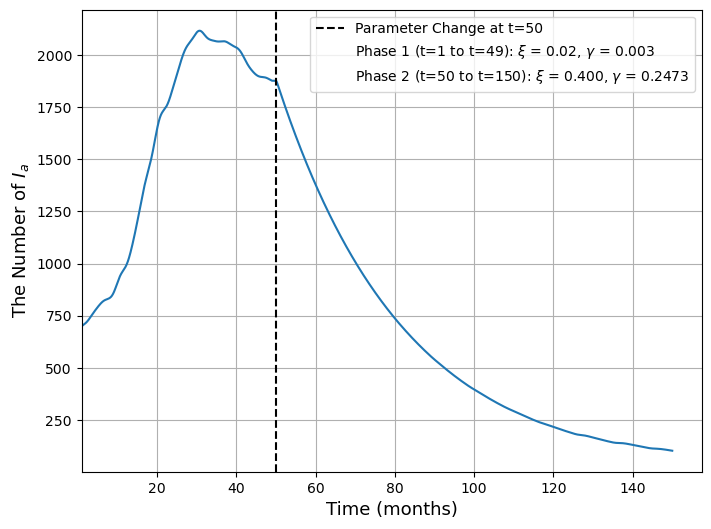

In [9]:
plt.figure(figsize=(8, 6))
#plt.plot(sirsol.t, sirsol.y[2], label='Combined Solution')
plt.plot(sirsol.t, sirsol.y[1])

# Add vertical line at t=49
plt.axvline(x=50, color='k', linestyle='--', label='Parameter Change at t=50')

# Custom legend based on parameter phases
plt.plot([], [], ' ', label=r'Phase 1 (t=1 to t=49): $\xi$ = 0.02, $\gamma$ = 0.003')
plt.plot([], [], ' ', label=r'Phase 2 (t=50 to t=150): $\xi$ = 0.400, $\gamma$ = 0.2473')

plt.xlim(left=1)
plt.xlabel('Time (months)', fontsize=13)
plt.ylabel('The Number of $I_a$', fontsize=13)
#plt.title(r'Infected Asymptomatic Population ($I_a$) Over Time', fontsize=15)
plt.grid(True)
plt.legend()
plt.savefig('asydrop.jpg')
plt.show()

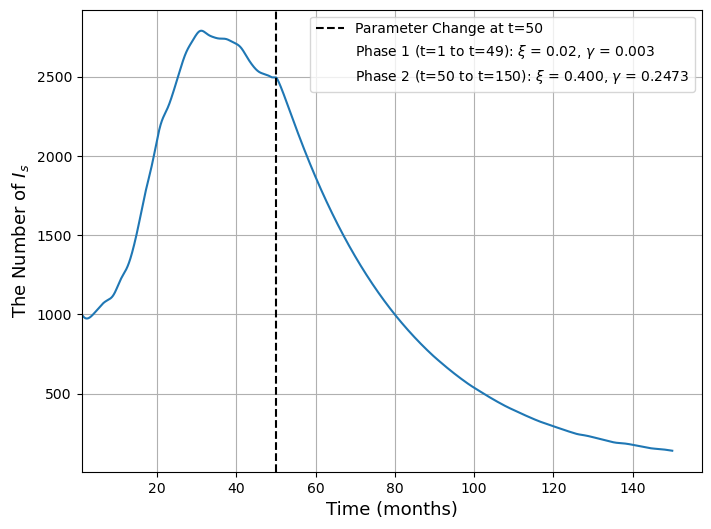

In [10]:
plt.figure(figsize=(8, 6))
#plt.plot(sirsol.t, sirsol.y[2], label='Combined Solution')
plt.plot(sirsol.t, sirsol.y[2])

# Add vertical line at t=49
plt.axvline(x=50, color='k', linestyle='--', label='Parameter Change at t=50')

# Custom legend based on parameter phases
plt.plot([], [], ' ', label=r'Phase 1 (t=1 to t=49): $\xi$ = 0.02, $\gamma$ = 0.003')
plt.plot([], [], ' ', label=r'Phase 2 (t=50 to t=150): $\xi$ = 0.400, $\gamma$ = 0.2473')

plt.xlim(left=1)
plt.xlabel('Time (months)', fontsize=13)
plt.ylabel('The Number of $I_s$', fontsize=13)
#plt.title(r'Infected Asymptomatic Population ($I_a$) Over Time', fontsize=15)
plt.grid(True)
plt.legend()
plt.savefig('symdrop.jpg')
plt.show()